# 02. Exploratory Data Analysis (EDA)
**Objective:** Explore the data to understand the target variable, find data issues, and identify key patterns related to loan default.

## 1. Load Data
Load the dataset and convert numbers stored as text (containing symbols like `$`, `x`, `&`) into standard numeric values.

In [6]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress minor warnings for clean presentation
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load data
data_path = 'data/raw/Train_Dataset.csv' if os.path.exists('data/raw/Train_Dataset.csv') else '../data/raw/Train_Dataset.csv'
df = pd.read_csv(data_path, low_memory=False)

# Convert columns with dirty strings to numeric (coercing symbols to NaN)
num_cols = [
    'Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Employed_Days', 
    'Score_Source_1', 'Score_Source_2', 'Score_Source_3', 'Age_Days', 
    'Registration_Days', 'ID_Days', 'Phone_Change', 'Cleint_City_Rating', 'Child_Count'
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Dataset loaded:", df.shape[0], "rows and", df.shape[1], "columns.")

Dataset loaded: 121856 rows and 40 columns.


## 2. Target Distribution (`Default`)
Check the proportion of customers who repaid (`0`) versus those who defaulted (`1`).

Class counts:
Default
0    112011
1      9845
Name: count, dtype: int64

Class percentages:
Default
0    91.92
1     8.08
Name: proportion, dtype: float64


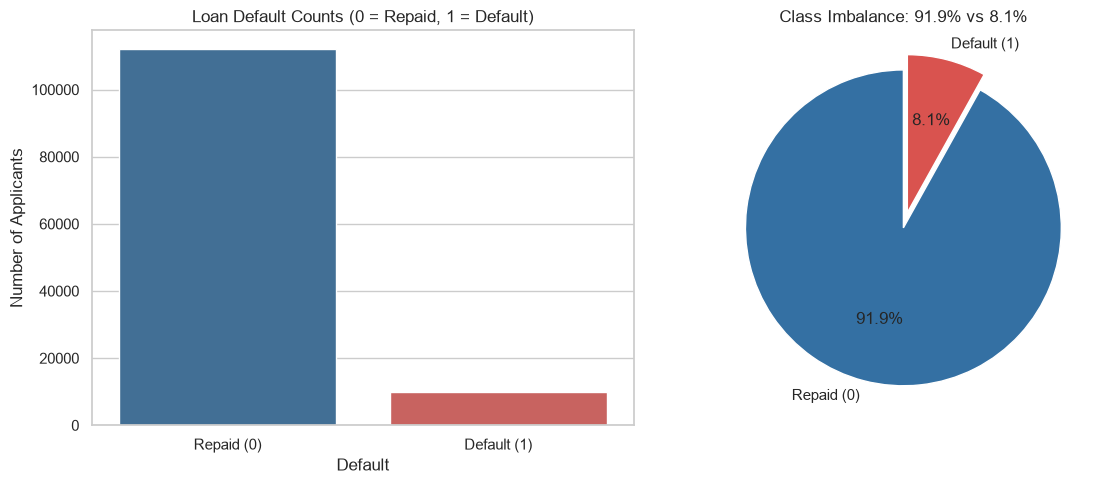

In [7]:
# Display class frequencies
print("Class counts:")
print(df['Default'].value_counts())
print("\nClass percentages:")
print((df['Default'].value_counts(normalize=True) * 100).round(2))

# Plot countplot and pie chart side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Countplot
sns.countplot(x='Default', hue='Default', data=df, palette=['#3470a3', '#d9534f'], legend=False, ax=axes[0])
axes[0].set_title('Loan Default Counts (0 = Repaid, 1 = Default)')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Repaid (0)', 'Default (1)'])

# 2. Pie chart
df['Default'].value_counts().plot.pie(
    autopct='%.1f%%', 
    labels=['Repaid (0)', 'Default (1)'], 
    colors=['#3470a3', '#d9534f'],
    explode=[0, 0.1],
    startangle=90,
    ax=axes[1]
)
axes[1].set_title('Class Imbalance: 91.9% vs 8.1%')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Key Takeaways:
- **Class Imbalance:** 91.9% repaid their loans, while only 8.1% defaulted.
- **Accuracy is Misleading:** A model that predicts "repaid" for everyone gets 91.9% accuracy, but catches zero defaulters.
- **What to Use:** We need metrics like **Precision, Recall, and F1-score** rather than simple accuracy.

## 3. `Employed_Days` Issue (`365243`)
The value `365243` appears many times. Since 365,243 days is about 1,000 years, this is a placeholder value, not real work experience.

Employed_Days == 365243 occurs in 21,098 rows (17.3% of data)

Cross-tabulation with Client_Income_Type:
                    Normal Employed  Sentinel (365243)
Client_Income_Type                                    
Businessman                       1                  0
Commercial                    27764                  0
Govt Job                       8303                  0
Maternity leave                   2                  0
Retired                         634              20409
Service                       61028                  0
Student                           8                  0
Unemployed                        1                  5


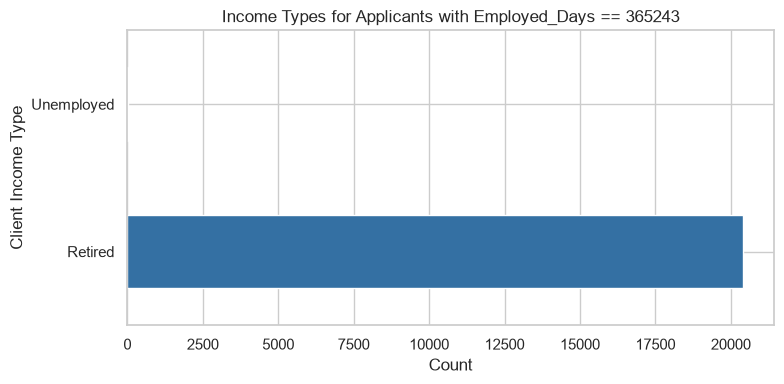

In [8]:
# Count occurrences of 365243
sentinel_count = (df['Employed_Days'] == 365243).sum()
sentinel_pct = (sentinel_count / len(df)) * 100
print(f"Employed_Days == 365243 occurs in {sentinel_count:,} rows ({sentinel_pct:.1f}% of data)")

# Cross-tabulation with Client_Income_Type
ct = pd.crosstab(df['Client_Income_Type'], df['Employed_Days'] == 365243)
ct.columns = ['Normal Employed', 'Sentinel (365243)']
print("\nCross-tabulation with Client_Income_Type:")
print(ct)

# Simple horizontal bar plot
plt.figure(figsize=(8, 4))
df[df['Employed_Days'] == 365243]['Client_Income_Type'].value_counts().plot(kind='barh', color='#3470a3')
plt.title('Income Types for Applicants with Employed_Days == 365243')
plt.xlabel('Count')
plt.ylabel('Client Income Type')
plt.tight_layout()
plt.show()


### Key Takeaways:
- **Common Placeholder:** The number 365,243 appears in **21,098 rows (17.3%)**.
- **Mostly Retired:** Almost all of these customers (**96.7%**) are **Retired**, and a few are **Unemployed**.
- **Next Step:** In preprocessing, replace 365,243 with 0 or NaN, and add an `Is_Retired` column so models are not confused.

## 4. Comparing Income, Loan Amount, and Payment
Compare income, loan amount, and monthly payment for defaulters vs. non-defaulters using boxplots.

Median values by Default status:
         Client_Income  Credit_Amount  Loan_Annuity
Default                                            
0              14850.0        51856.2      2497.050
1              13500.0        49752.0      2528.325


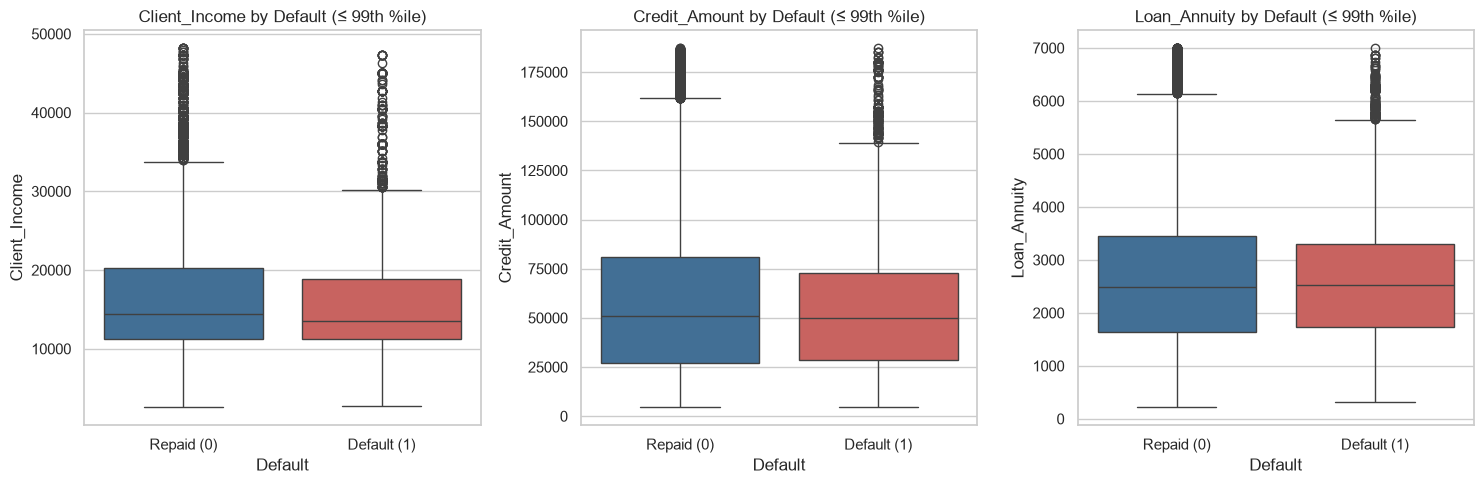

In [9]:
# Compare median values
print("Median values by Default status:")
print(df.groupby('Default')[['Client_Income', 'Credit_Amount', 'Loan_Annuity']].median())

# Plot boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fin_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity']

for i, col in enumerate(fin_cols):
    # Cap at 99th percentile for clean boxplot visualization
    limit = df[col].quantile(0.99)
    sns.boxplot(
        x='Default', 
        y=col, 
        hue='Default',
        data=df[df[col] <= limit], 
        palette=['#3470a3', '#d9534f'], 
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(f'{col} by Default (≤ 99th %ile)')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Repaid (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

### Key Takeaways:
- **Income:** Defaulters have slightly lower median income ($13,500 vs. $14,850).
- **Loan Amount:** Both groups borrow similar loan amounts.
- **Monthly Payment:** Monthly payments are almost the same, meaning defaulters spend a bigger share of their income on loan payments.

## 5. Credit Scores (`Score_Source_1, 2, 3`)
Compare credit bureau scores for borrowers who repaid vs. borrowers who defaulted.

Median Credit Scores by Default status:
         Score_Source_1  Score_Source_2  Score_Source_3
Default                                                
0              0.515809        0.572589        0.546023
1              0.367457        0.443746        0.385915


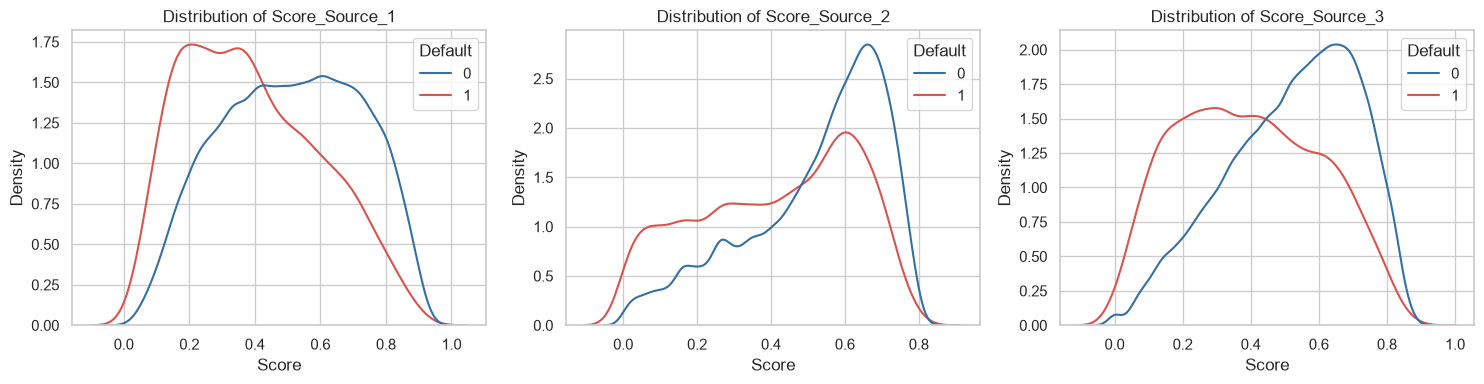

In [10]:
# Display median scores
print("Median Credit Scores by Default status:")
print(df.groupby('Default')[['Score_Source_1', 'Score_Source_2', 'Score_Source_3']].median())

# Plot KDE distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scores = ['Score_Source_1', 'Score_Source_2', 'Score_Source_3']

for i, col in enumerate(scores):
    # Valid 0-1 range (Score_Source_2 has a few entries of 100)
    valid = df[(df[col] >= 0) & (df[col] <= 1)]
    sns.kdeplot(
        data=valid, 
        x=col, 
        hue='Default', 
        common_norm=False, 
        palette=['#3470a3', '#d9534f'], 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Score')

plt.tight_layout()
plt.show()


### Key Takeaways:
- **Clear Difference:** Defaulters have noticeably lower credit scores across all three sources.
- **Strongest Predictors:** These credit scores are the most useful features for predicting default.
- **Missing Data:** Many applicants are missing Score 1, so we need to handle missing values properly in preprocessing.